<h1>Machine Learning + Agentic AI: A Complete Tutotial</h1>
<p><b>(In Python + Langgraph)</b></p>

<h2>Learning Objective</h2>
<p></p>- How to use machine learning to make predictions
<p></p>- How to use agentic AI for automation
<p></p>- How to integrate Machine Learning Models with AI Agents
<p></p><b>Complete solution available on Github</b>

<h2>Use-case: Customer Retention (Telecomunication Industry)</h2>
<p>1. <b>Machine Learning:</b>Identify customers who are likely to churn (leave)
<p>2. <b>Agentic AI:</b>AI Agent which will sent <b>customized</b> emails to customer to retain them. 
    <p>The emails are generated are not generaric emails, but are based on predicted reasons for churn

<h2>Solution</h2>

![title](IMG_0070.PNG)

# 📡 TelConnect — Churn Prediction Pipeline

**Goal:** Train a binary classifier to predict customer churn, evaluate three models, and explain predictions with SHAP.

| Step | Description |
|------|-------------|
| 1 | Setup & imports |
| 2 | Load & inspect data |
| 3 | Clean data |
| 4 | Feature engineering |
| 5 | Preprocessing pipeline |
| 6 | Train & evaluate models |
| 7 | Model comparison |
| 8 | SHAP explainability |
| 9 | Save artefacts |


## 1 · Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)

print("All libraries imported ✓")

All libraries imported ✓


## 2 · Load & Inspect Data

We load the training CSV and check shape, target distribution, and a sample of rows.


In [2]:
DATA_PATH = "./data/telco_customer_churn_train.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape : {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape : (7032, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [4]:
print("Churn distribution:")
print(df["Churn"].value_counts())
print(f"\nChurn rate: {df['Churn'].mean():.1%}")

Churn distribution:
Churn
0    5166
1    1866
Name: count, dtype: int64

Churn rate: 26.5%


In [5]:
# Quick look at nulls and dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


## 3 · Clean Data

Two issues to fix:
- **TotalCharges** — blank for new customers (tenure = 0). Coerce to numeric, fill NaN with median.
- **customerID** — unique identifier with no predictive value; drop it.


In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df.drop(columns=["customerID"], inplace=True)

print(f"Missing values after cleaning:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print("\nData clean ✓")

Missing values after cleaning:
Series([], dtype: int64)

Data clean ✓


## 4 · Feature Engineering

Two new features:

| Feature | Logic | Why |
|---------|-------|-----|
| `tenure_group` | Bin tenure into 4 lifecycle stages | Captures non-linear loyalty patterns |
| `charges_ratio` | TotalCharges ÷ tenure | Normalised avg monthly spend across all customer ages |


In [7]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 mo", "12-24 mo", "24-48 mo", "48-72 mo"],
    include_lowest=True,
)

df["charges_ratio"] = df["TotalCharges"] / df["tenure"].replace(0, 1)

print("New features added:")
print(df[["tenure", "tenure_group", "TotalCharges", "charges_ratio"]].head(5))

New features added:
   tenure tenure_group  TotalCharges  charges_ratio
0       1      0-12 mo         29.85      29.850000
1      34     24-48 mo       1889.50      55.573529
2       2      0-12 mo        108.15      54.075000
3      45     24-48 mo       1840.75      40.905556
4       2      0-12 mo        151.65      75.825000


## 5 · Split Features / Target & Build Preprocessor

- Numeric columns → `StandardScaler`
- Categorical columns → `OneHotEncoder` (with `handle_unknown="ignore"` for production safety)

Both branches are combined in a `ColumnTransformer`, then wrapped with the classifier in a single `Pipeline` to prevent data leakage.


In [8]:
TARGET = "Churn"
X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_cols     = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numeric features    ({len(numeric_cols)}) : {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Numeric features    (5) : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'charges_ratio']
Categorical features (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),                                           numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Train size: 5625  |  Test size: 1407


## 6 · Train & Evaluate Three Models

We train Logistic Regression, Random Forest, and Gradient Boosting — all with `class_weight="balanced"` to handle the 73/27 class imbalance.

Each model is evaluated with:
- **Test ROC-AUC**
- **5-fold cross-validated AUC** (on training set)
- **Classification report** (precision, recall, F1 per class)


In [10]:
models = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest":        RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
}

results = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    auc    = roc_auc_score(y_test, y_prob)
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc").mean()

    results[name] = {"pipe": pipe, "y_pred": y_pred, "y_prob": y_prob,
                     "auc": auc, "cv_auc": cv_auc}

    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"  Test AUC : {auc:.4f}   CV AUC : {cv_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Churn", "Churn"]))


──────────────────────────────────────────────────
  Logistic Regression
  Test AUC : 0.8519   CV AUC : 0.8432
              precision    recall  f1-score   support

   Not Churn       0.91      0.72      0.80      1034
       Churn       0.51      0.81      0.62       373

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407


──────────────────────────────────────────────────
  Random Forest
  Test AUC : 0.8336   CV AUC : 0.8289
              precision    recall  f1-score   support

   Not Churn       0.83      0.89      0.86      1034
       Churn       0.62      0.49      0.55       373

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407


──────────────────────────────────────────────────
  Gradient Boosting
  Test AUC : 0.8550   CV AUC : 0.8445
              prec

## 7 · Model Comparison & Best Model

Best model: Gradient Boosting  (AUC 0.8550)


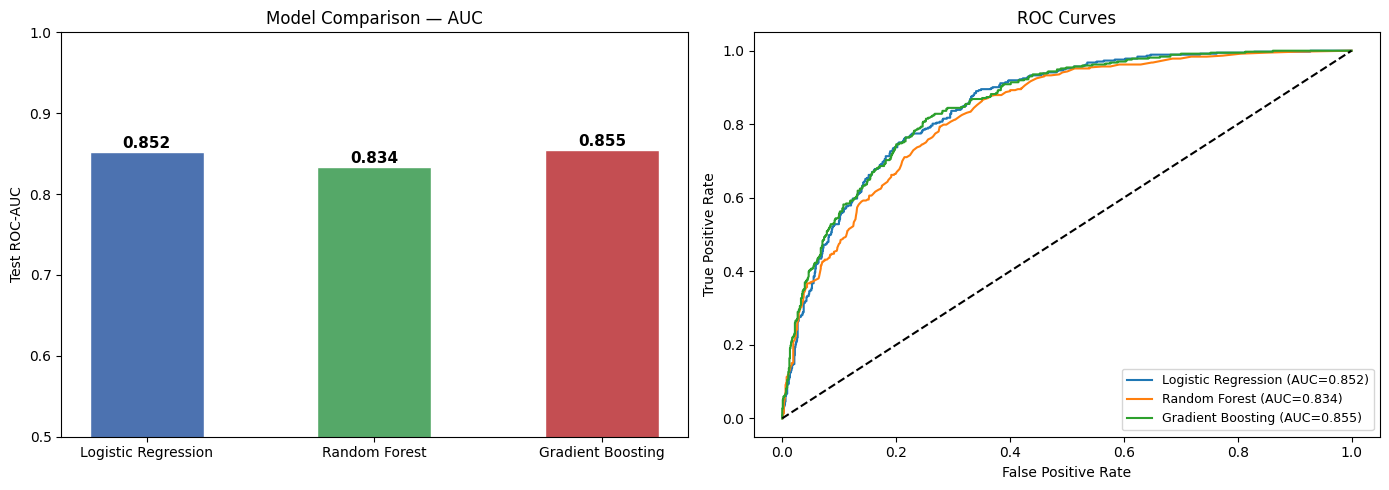

In [11]:
best_name = max(results, key=lambda k: results[k]["auc"])
best      = results[best_name]

print(f"Best model: {best_name}  (AUC {best['auc']:.4f})")

# ── AUC comparison bar chart ──────────────────────────────────────
names = list(results.keys())
aucs  = [results[n]["auc"] for n in names]
colors = ["#4c72b0", "#55a868", "#c44e52"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(names, aucs, color=colors, edgecolor="white", width=0.5)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Model Comparison — AUC")
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{auc:.3f}", ha="center", fontsize=11, fontweight="bold")

# ── ROC curves ────────────────────────────────────────────────────
ax = axes[1]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("churn_model_comparison.png", dpi=150)
plt.show()

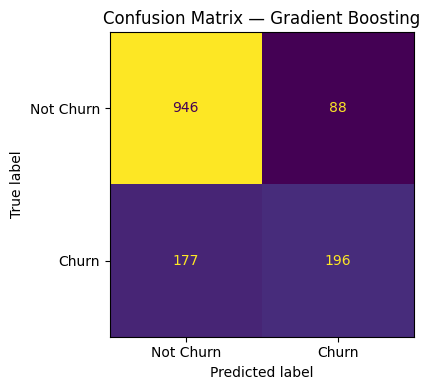

1034 373


In [19]:
# Confusion matrix for best model
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, best["y_pred"])
ConfusionMatrixDisplay(cm, display_labels=["Not Churn", "Churn"]).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("churn_evaluation.png", dpi=150)
plt.show()
print (946+88, 177+196)

## 8 · SHAP Explainability

`shap.TreeExplainer` works directly on the Gradient Boosting classifier.
We transform the test set through the preprocessor first to get the feature matrix, then compute SHAP values.

| Plot | What it shows |
|------|---------------|
| **Beeswarm** | Every test customer as a dot — position = SHAP impact, colour = feature value |
| **Bar** | Global mean \|SHAP\| — overall feature importance ranking |


In [13]:
best_pipe = best["pipe"]
clf       = best_pipe.named_steps["clf"]
prep      = best_pipe.named_steps["prep"]

ohe_cols      = prep.transformers_[1][1].get_feature_names_out(categorical_cols)
feature_names = np.concatenate([numeric_cols, ohe_cols])

X_test_transformed = prep.transform(X_test)

print("Computing SHAP values …")
explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_transformed)
print(f"SHAP array shape: {shap_values.shape}")

Computing SHAP values …
SHAP array shape: (1407, 50)


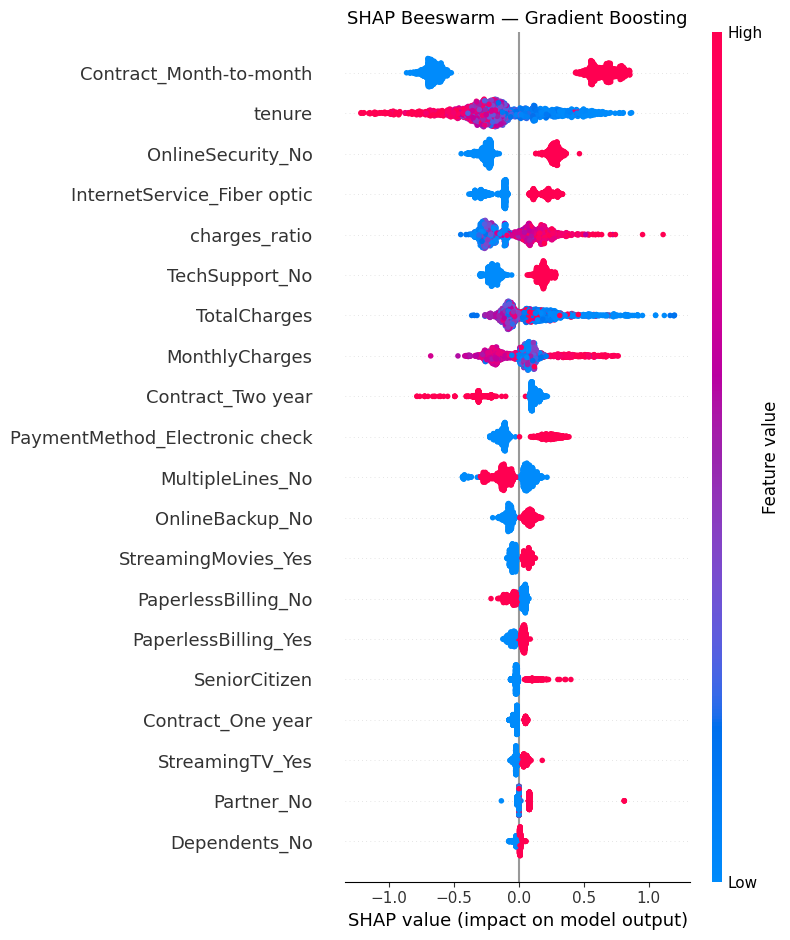

In [14]:
# Beeswarm (summary) plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,
    plot_type="dot", show=False, max_display=20,
)
plt.title(f"SHAP Beeswarm — {best_name}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

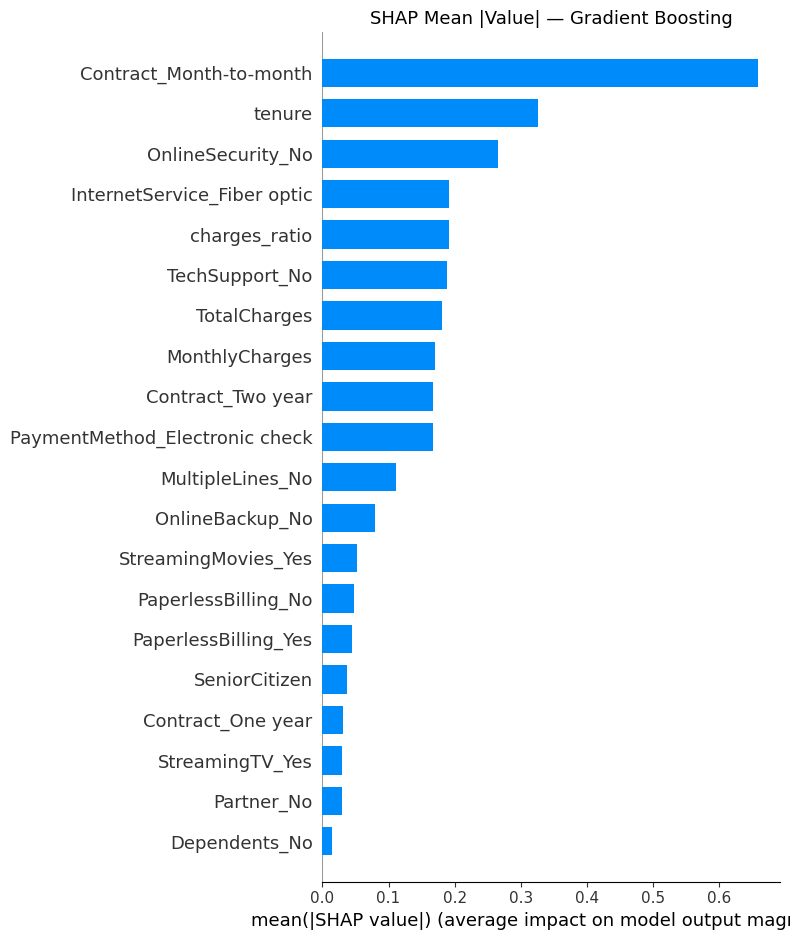

In [15]:
# Bar plot — mean |SHAP|
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,
    plot_type="bar", show=False, max_display=20,
)
plt.title(f"SHAP Mean |Value| — {best_name}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 · Save Model Artefacts

Both files are consumed by `churn_agent.ipynb` at inference time.

| File | Contents |
|------|----------|
| `churn_model.pkl` | Full sklearn Pipeline (preprocessor + Gradient Boosting classifier) |
| `churn_metadata.pkl` | Column lists and OHE feature names |


In [16]:
joblib.dump(best_pipe, "churn_model.pkl")
joblib.dump(
    {
        "numeric_cols":    numeric_cols,
        "categorical_cols": categorical_cols,
        "feature_names":   feature_names.tolist(),
    },
    "churn_metadata.pkl",
)

print("churn_model.pkl    saved ✓")
print("churn_metadata.pkl saved ✓")

churn_model.pkl    saved ✓
churn_metadata.pkl saved ✓


---
### Summary

| Metric | Value |
|--------|-------|
| Best model | Gradient Boosting |
| Test AUC | **0.855** |
| CV AUC (5-fold) | **0.845** |
| Accuracy | **81%** |
| Top churn driver | Month-to-month contract (SHAP 0.42) |

➡ Next: open **`churn_agent.ipynb`** to run the LangGraph agent.
